In [1]:
from astropy.io import fits
from astropy.timeseries import LombScargle

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import readsav
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [2]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')

In [3]:
c = 3e8
# extract data
wl = data_rv['lambd']
rv = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.arange(0, len(data_spectra) * 144, 144) / 60 / 24  # time in days

In [4]:
spectra_matrix = data_spectra
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [5]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [9.92803806e-01 6.26560296e-03 8.63973395e-04 3.85380068e-05
 2.41456299e-05 2.64868120e-06 8.36598837e-07 1.80366280e-07
 1.30135383e-07 8.46910387e-08 2.39329689e-08 7.45164719e-09
 2.45115279e-09 1.75363266e-09 1.46686893e-09 3.01420518e-10
 2.33800456e-10 2.18477225e-10 2.13561898e-10 2.09785696e-10]


In [19]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
sigma = .000001
mean_maxes = t.calculate_pca_significance(n_realizations, n_components, spectra_centered, sigma)  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

100%|██████████| 20/20 [00:00<00:00, 30.46it/s]


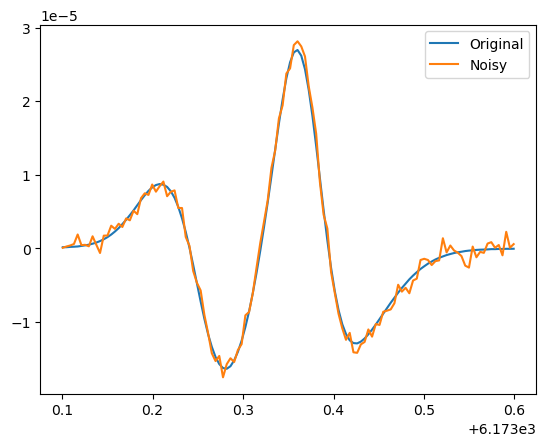

In [ ]:
snr = 1000000
spectra_noisy = spectra_centered + np.random.normal(0, 1 / snr, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.legend()
plt.show()

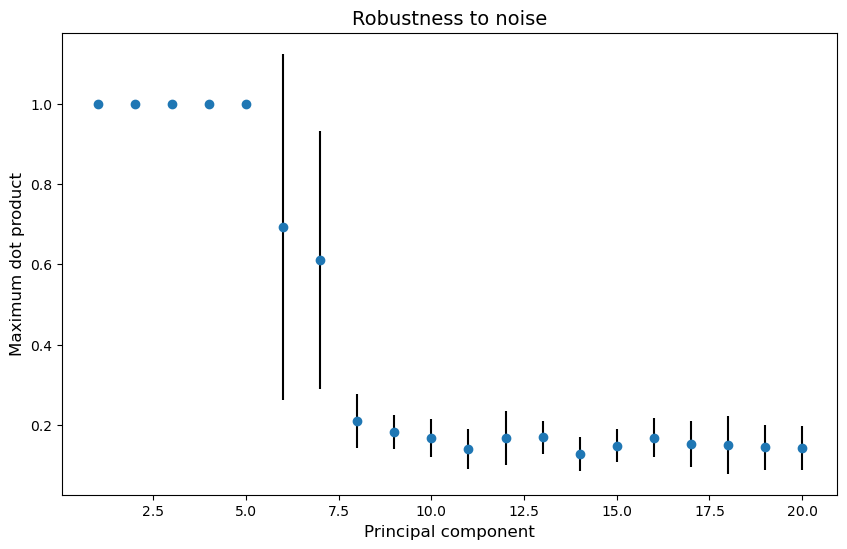

In [21]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('Robustness to noise', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [22]:
dt = times[1] - times[0]
sp = np.array([np.fft.fft(pcs[:, i]) for i in range(n_components)])
freq = np.array([np.fft.fftfreq(pcs[:, i].shape[0], dt) for i in range(n_components)])
power = np.abs(sp)**2

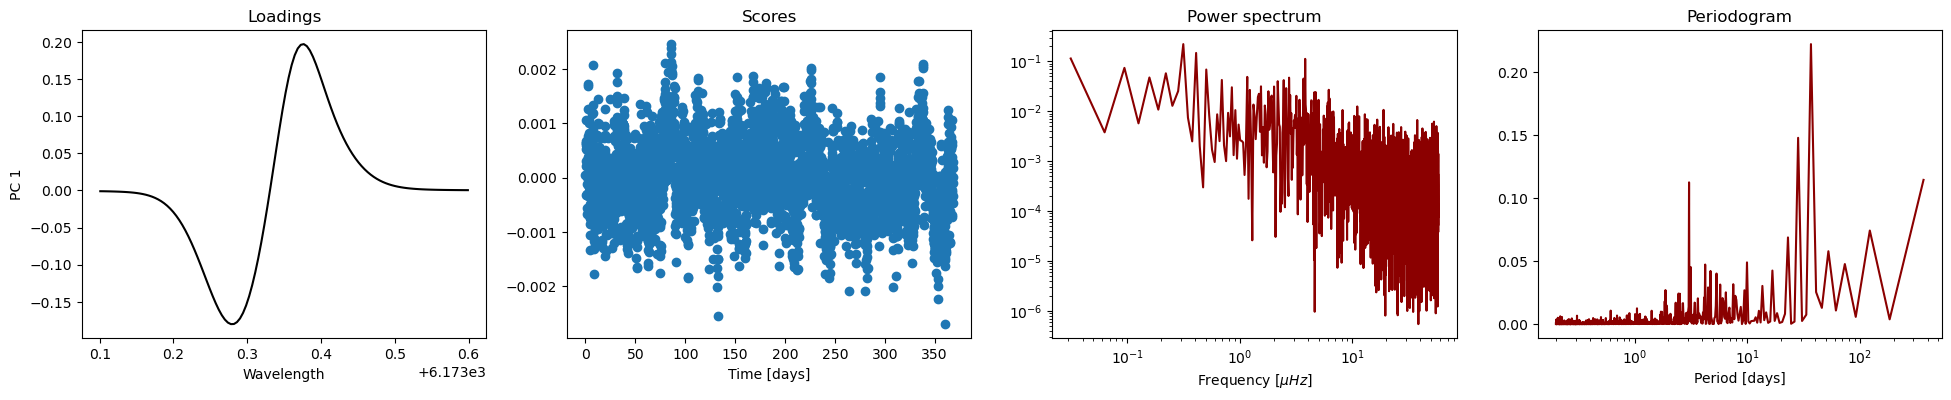

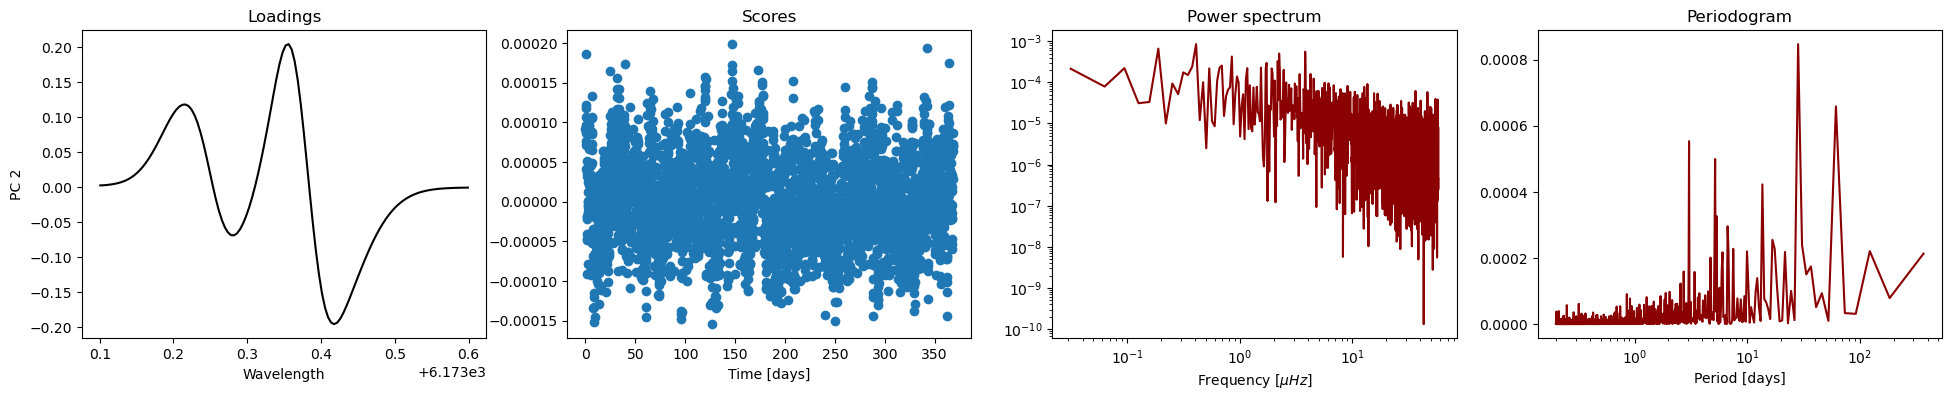

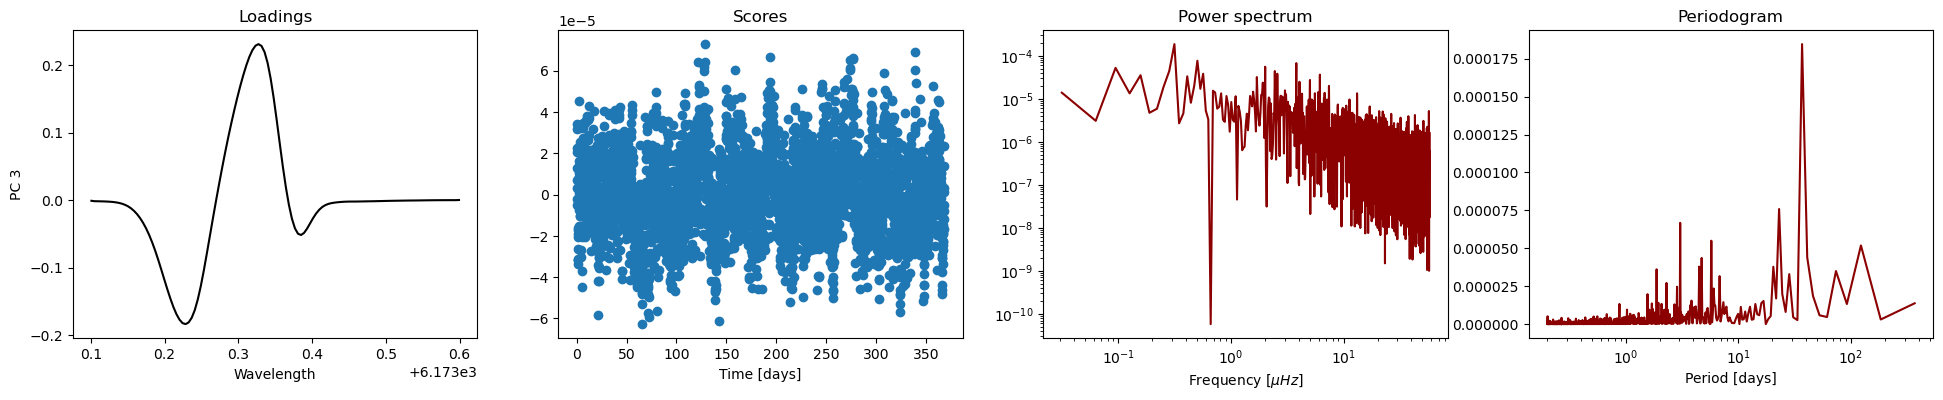

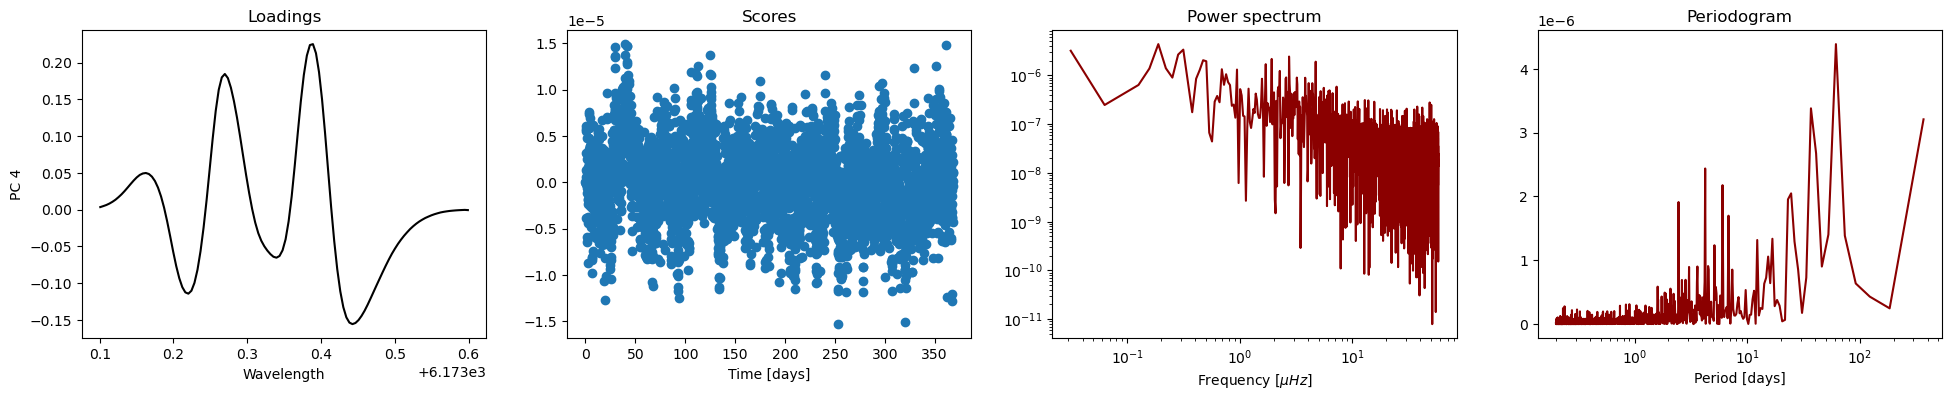

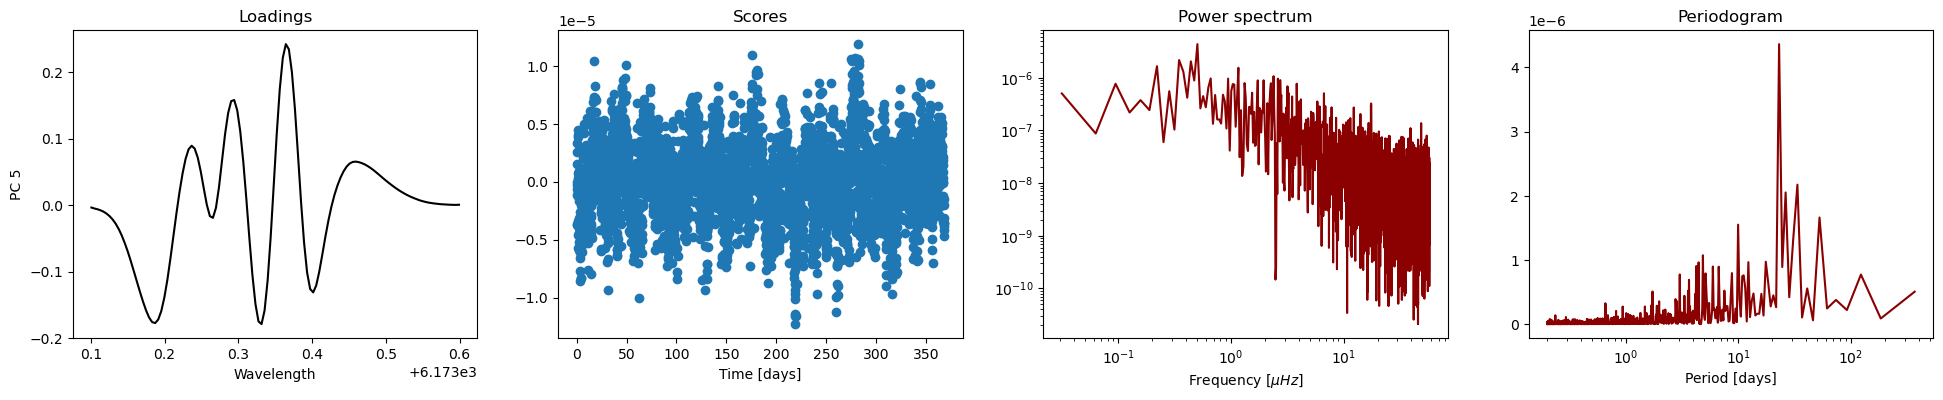

In [23]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] / 86400 * 10**6, power[i][mask], color='darkred')  # frequency divided by 86400 to pass from days^-1 to Hz, then multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Power spectrum', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')
    
    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram', size=12)
    axs[3].set_xlabel('Period [days]')

    plt.show()